# Cross-Domain Visual Translator

For each digit **0-8**, find the **shape**, **bird**, and **object** whose *silhouette* most resembles it, discovered from edge/shape (HOG) features nothing labelled by hand.

**What's new in  (matching quality):**
- **Mean-centering** subtracts the "everything looks alike" common component, so similarity scores spread out.
- **One-to-one matching** (Hungarian assignment) no bird/object can be reused; every digit gets a distinct match.
- **Edge silhouettes** for birds & objects matches follow contour, not photo brightness.

**Output:** four aligned **3×3 matrices** (digits 0-8), one per dataset. Position (row, col) is the *same digit* in every grid, so the digit matrix and the bird matrix line up cell-for-cell ready to animate one into another.
```
0 1 2      the DIGIT matrix, the SHAPE matrix, the BIRD matrix and the
3 4 5  ->  OBJECT matrix all share this layout, so cell (0,0) is digit 0
6 7 8      and digit-0's matched shape / bird / object in the others.
```

## 1. (Colab only) Mount Drive + install deps

In [1]:
from google.colab import drive
drive.mount('/content/drive')
!pip -q install scikit-image matplotlib pillow scipy

Mounted at /content/drive


## 2. Config edit `BASE_DIR` to your folder

In [2]:
CONFIG = {
    "BASE_DIR": "/content/drive/MyDrive/visual-mapping-data",

    "N_DIGIT_EXAMPLES_PER_CLASS": 40,
    "N_SHAPES": 3000,
    "N_BIRDS": 1200,
    "N_OBJECTS": 3000,

    "IMG_SIZE": 64,
    "REPRESENTATION": "hog",        # "hog" or "pixels"
    "CROP_BIRDS_TO_BBOX": True,

    # ---  matching improvements ---
    "MEAN_CENTER": True,            # spread out the similarity scores
    "UNIQUE_MATCHES": True,         # one-to-one: no target reused
    "EDGE_MATCH_DOMAINS": ["bird", "object"],  # match on contour, not brightness

    "WORK_DIR": None,
    "RANDOM_SEED": 0,
}

## 3. Imports + helpers

In [3]:
import os, glob, struct, pickle, tarfile, math
import numpy as np
from skimage.transform import resize
from skimage.color import rgb2gray
from skimage.filters import sobel
from skimage.feature import hog
import matplotlib.pyplot as plt


def find_one(base, pattern):
    hits = sorted(glob.glob(os.path.join(base, "**", pattern), recursive=True))
    return hits[0] if hits else None


def work_dir():
    wd = CONFIG["WORK_DIR"] or os.path.join(CONFIG["BASE_DIR"], "_extracted")
    os.makedirs(wd, exist_ok=True)
    return wd


def to_feature_image(img, size):
    """Any image -> float grayscale, resized, contrast-normalized to [0,1]. (for display)"""
    img = np.asarray(img)
    if img.ndim == 3:
        img = rgb2gray(img)
    img = img.astype(np.float32)
    img = resize(img, (size, size), anti_aliasing=True)
    rng = img.max() - img.min()
    return (img - img.min()) / (rng + 1e-8)


def to_edge(img64):
    """Sobel edge magnitude of a normalized grayscale image (contour, not brightness)."""
    e = sobel(img64)
    return (e / (e.max() + 1e-8)).astype(np.float32)


def extract_feature(img64, edge=False):
    base = to_edge(img64) if edge else img64
    if CONFIG["REPRESENTATION"] == "pixels":
        return base.ravel().astype(np.float32)
    return hog(base, orientations=9, pixels_per_cell=(8, 8),
               cells_per_block=(2, 2), block_norm="L2-Hys").astype(np.float32)


def features_for(images, size, edge=False):
    return np.stack([extract_feature(to_feature_image(im, size), edge) for im in images])


def cosine_matrix(A, B):
    An = A / (np.linalg.norm(A, axis=1, keepdims=True) + 1e-8)
    Bn = B / (np.linalg.norm(B, axis=1, keepdims=True) + 1e-8)
    return An @ Bn.T

## 4. Dataset loaders

In [4]:
def load_mnist(base, per_class):
    img_path = find_one(base, "t10k-images.idx3-ubyte") or find_one(base, "*images*idx3*")
    lbl_path = find_one(base, "t10k-labels.idx1-ubyte") or find_one(base, "*labels*idx1*")
    if not img_path or not lbl_path:
        raise FileNotFoundError("MNIST idx files not found under BASE_DIR/mnist-digits/archive")
    with open(img_path, "rb") as f:
        _, num, rows, cols = struct.unpack(">IIII", f.read(16))
        images = np.frombuffer(f.read(), dtype=np.uint8).reshape(num, rows, cols)
    with open(lbl_path, "rb") as f:
        _, num = struct.unpack(">II", f.read(8))
        labels = np.frombuffer(f.read(), dtype=np.uint8)
    by_digit = {}
    for d in range(10):
        idx = np.where(labels == d)[0][:per_class]
        by_digit[d] = [images[i] for i in idx]
    return by_digit


def load_dsprites(base, n):
    npz = find_one(base, "dsprites_ndarray_*64x64.npz") or find_one(base, "dsprites*.npz")
    if not npz:
        raise FileNotFoundError("dSprites .npz not found under BASE_DIR/dsprite-synthetic-shapes")
    d = np.load(npz, allow_pickle=True, encoding="latin1")
    imgs = d["imgs"]
    rng = np.random.default_rng(CONFIG["RANDOM_SEED"])
    idx = rng.choice(len(imgs), size=min(n, len(imgs)), replace=False)
    return [imgs[i] * 255 for i in idx]


def load_cifar(base, n):
    tar_path = find_one(base, "cifar-10-python.tar.gz") or find_one(base, "cifar-10*.tar.gz")
    if not tar_path:
        raise FileNotFoundError("CIFAR-10 tar.gz not found under BASE_DIR/cifar10-objects")
    images = []
    with tarfile.open(tar_path, "r:gz") as tar:
        for m in [m for m in tar.getmembers() if "data_batch" in m.name]:
            d = pickle.load(tar.extractfile(m), encoding="bytes")
            data = d[b"data"].reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
            images.extend(list(data))
            if len(images) >= n:
                break
    rng = np.random.default_rng(CONFIG["RANDOM_SEED"])
    idx = rng.choice(len(images), size=min(n, len(images)), replace=False)
    return [images[i] for i in idx]


def _ensure_cub_extracted(base):
    tgz = find_one(base, "CUB_200_2011.tgz")
    if not tgz:
        raise FileNotFoundError("CUB_200_2011.tgz not found under BASE_DIR/cup200-2011-birds")
    root = os.path.join(work_dir(), "CUB_200_2011")
    if not os.path.isdir(os.path.join(root, "images")):
        print("Extracting CUB archive (one-time, ~1 GB)...")
        with tarfile.open(tgz, "r:gz") as tar:
            tar.extractall(work_dir())
    return root


def load_cub(base, n):
    from PIL import Image
    root = _ensure_cub_extracted(base)
    images_dir = os.path.join(root, "images")
    bbox = {}
    if CONFIG["CROP_BIRDS_TO_BBOX"]:
        idx_txt = os.path.join(root, "images.txt")
        box_txt = os.path.join(root, "bounding_boxes.txt")
        if os.path.exists(idx_txt) and os.path.exists(box_txt):
            id2name = {}
            with open(idx_txt) as f:
                for line in f:
                    i, name = line.split()
                    id2name[i] = name
            with open(box_txt) as f:
                for line in f:
                    i, x, y, w, h = line.split()
                    bbox[id2name[i]] = (float(x), float(y), float(w), float(h))
    all_imgs = sorted(glob.glob(os.path.join(images_dir, "*", "*.jpg")))
    rng = np.random.default_rng(CONFIG["RANDOM_SEED"])
    chosen = rng.choice(len(all_imgs), size=min(n, len(all_imgs)), replace=False)
    out = []
    for i in chosen:
        p = all_imgs[i]
        try:
            im = Image.open(p).convert("RGB")
            rel = os.path.relpath(p, images_dir).replace("\\", "/")
            if rel in bbox:
                x, y, w, h = bbox[rel]
                im = im.crop((x, y, x + w, y + h))
            out.append(np.asarray(im))
        except Exception:
            continue
    return out

## 5. Matching () + the 3×3 matrix display

In [5]:
def build_digit_prototypes(mnist_by_digit, size):
    """One HOG vector per digit = mean HOG over its clean examples (+ a thumbnail)."""
    protos, thumbs = {}, {}
    for d in range(10):
        feats = features_for(mnist_by_digit[d], size, edge=False)
        protos[d] = feats.mean(axis=0)
        sims = cosine_matrix(feats, protos[d][None, :]).ravel()
        thumbs[d] = to_feature_image(mnist_by_digit[d][int(sims.argmax())], size)
    return protos, thumbs


def match_domain(proto_mat, target_feats, target_disp, n_digits=9):
    """Return (matched_images, sims) for digits 0..n_digits-1.
    Applies mean-centering and one-to-one (Hungarian) assignment per CONFIG."""
    mu = target_feats.mean(axis=0, keepdims=True) if CONFIG["MEAN_CENTER"] else 0.0
    S = cosine_matrix(proto_mat - mu, target_feats - mu)   # (10, N)
    S9 = S[:n_digits]
    if CONFIG["UNIQUE_MATCHES"]:
        try:
            from scipy.optimize import linear_sum_assignment
            _, cols = linear_sum_assignment(-S9)
        except Exception:
            cols, used = [], set()   # greedy fallback
            for i in range(n_digits):
                order = np.argsort(-S9[i])
                pick = next(j for j in order if j not in used)
                used.add(pick); cols.append(pick)
            cols = np.array(cols)
    else:
        cols = S9.argmax(axis=1)
    imgs = [target_disp[c] for c in cols]
    sims = [float(S9[i, c]) for i, c in enumerate(cols)]
    return imgs, sims


def render_matrix(images, sims, labels, title, out_path):
    """A clean 3x3 matrix of 9 images (digits 0-8), positionally aligned across datasets."""
    fig, axes = plt.subplots(3, 3, figsize=(6.6, 7.0))
    for i, ax in enumerate(axes.ravel()):
        ax.imshow(images[i], cmap="gray")
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title(str(labels[i]), fontsize=15, fontweight="bold", pad=4)
        if sims is not None:
            ax.set_xlabel(f"sim {sims[i]:.2f}", fontsize=9)
    fig.suptitle(title, fontsize=16, fontweight="bold", y=0.99)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    fig.savefig(out_path, dpi=140, bbox_inches="tight")
    plt.show()

## 6. produces four aligned 3×3 matrices
`gallery_matrix_digits/shapes/birds/objects.png`. Same digit in the same cell across all four the "number matrix" and its equivalents, ready to animate.

Loading MNIST digits...
Loading synthetic shapes (dSprites)...
Loading birds (CUB-200-2011)...
Loading objects (CIFAR-10)...
Building digit prototypes...
Extracting features + matching...
  features for shape (edge=False)...
  features for bird (edge=True)...
  features for object (edge=True)...

matched similarities (0-8):
  0:  shape~0.18   bird~0.32   object~0.43
  1:  shape~0.30   bird~0.31   object~0.55
  2:  shape~0.21   bird~0.34   object~0.33
  3:  shape~0.20   bird~0.28   object~0.35
  4:  shape~0.22   bird~0.31   object~0.34
  5:  shape~0.21   bird~0.27   object~0.37
  6:  shape~0.20   bird~0.30   object~0.38
  7:  shape~0.30   bird~0.33   object~0.30
  8:  shape~0.22   bird~0.38   object~0.38


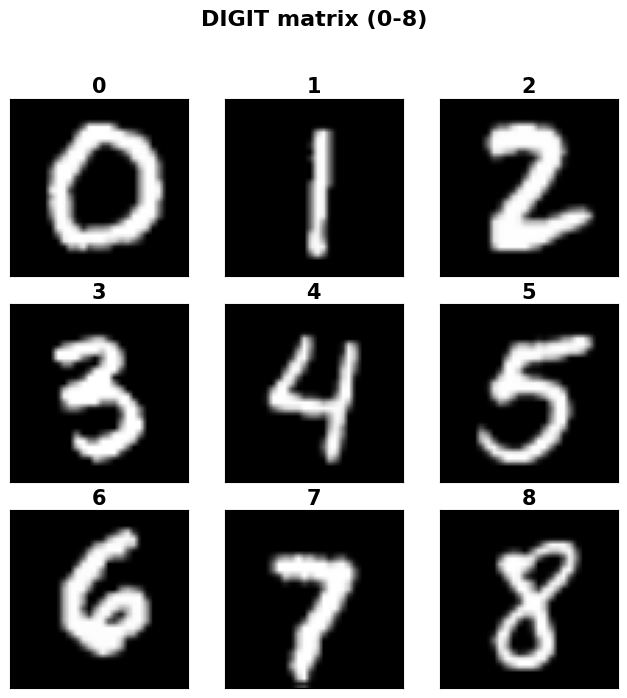

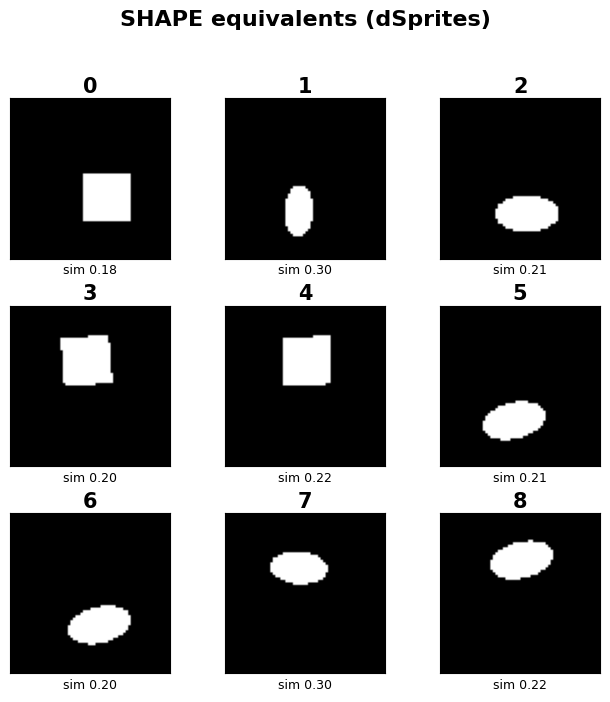

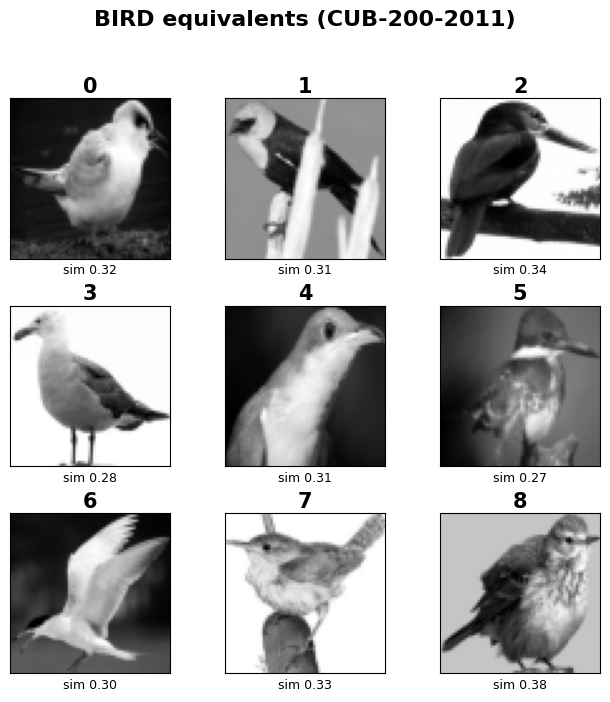

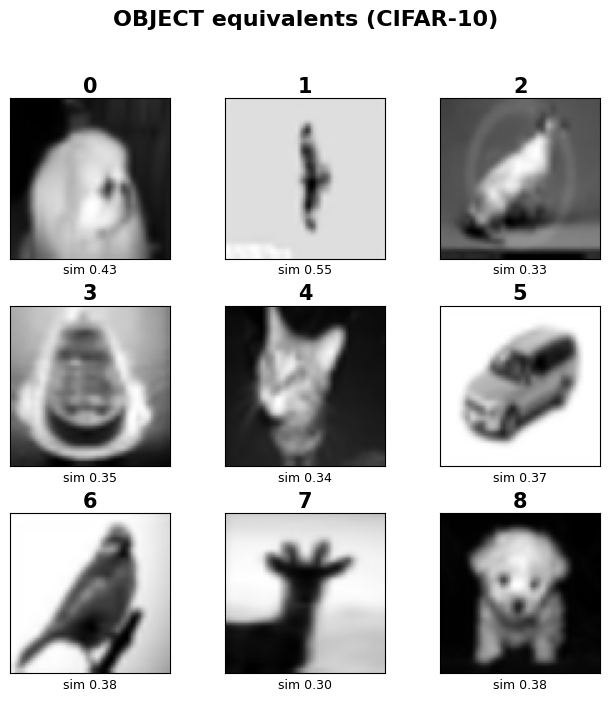


Saved: gallery_matrix_digits/shapes/birds/objects.png (aligned 3x3, ready to animate)


In [6]:
size = CONFIG["IMG_SIZE"]
NDIG = 9  # digits 0-8 -> a 3x3 matrix

print("Loading MNIST digits...")
mnist = load_mnist(CONFIG["BASE_DIR"], CONFIG["N_DIGIT_EXAMPLES_PER_CLASS"])
print("Loading synthetic shapes (dSprites)...")
shapes = load_dsprites(CONFIG["BASE_DIR"], CONFIG["N_SHAPES"])
print("Loading birds (CUB-200-2011)...")
birds = load_cub(CONFIG["BASE_DIR"], CONFIG["N_BIRDS"])
print("Loading objects (CIFAR-10)...")
objects = load_cifar(CONFIG["BASE_DIR"], CONFIG["N_OBJECTS"])

print("Building digit prototypes...")
protos, thumbs = build_digit_prototypes(mnist, size)
proto_mat = np.stack([protos[d] for d in range(10)])


def prep(target_imgs, name):
    edge = name in CONFIG["EDGE_MATCH_DOMAINS"]
    print(f"  features for {name} (edge={edge})...")
    feats = features_for(target_imgs, size, edge=edge)
    disp = [to_feature_image(im, size) for im in target_imgs]
    return feats, disp


print("Extracting features + matching...")
shape_feats, shape_disp = prep(shapes, "shape")
bird_feats,  bird_disp  = prep(birds, "bird")
obj_feats,   obj_disp   = prep(objects, "object")

shape_imgs, shape_sims = match_domain(proto_mat, shape_feats, shape_disp, NDIG)
bird_imgs,  bird_sims  = match_domain(proto_mat, bird_feats,  bird_disp,  NDIG)
obj_imgs,   obj_sims   = match_domain(proto_mat, obj_feats,   obj_disp,   NDIG)

labels = list(range(NDIG))
print("\nmatched similarities (0-8):")
for i in range(NDIG):
    print(f"  {i}:  shape~{shape_sims[i]:.2f}   bird~{bird_sims[i]:.2f}   object~{obj_sims[i]:.2f}")

# Matrix 1: the DIGIT matrix (the "number matrix")
render_matrix([thumbs[d] for d in range(NDIG)], None, labels,
              "DIGIT matrix (0-8)", "gallery_matrix_digits.png")
# Matrices 2-4: each digit's equivalent in the other datasets, same cell positions
render_matrix(shape_imgs, shape_sims, labels, "SHAPE equivalents (dSprites)", "gallery_matrix_shapes.png")
render_matrix(bird_imgs,  bird_sims,  labels, "BIRD equivalents (CUB-200-2011)", "gallery_matrix_birds.png")
render_matrix(obj_imgs,   obj_sims,   labels, "OBJECT equivalents (CIFAR-10)", "gallery_matrix_objects.png")
print("\nSaved: gallery_matrix_digits/shapes/birds/objects.png (aligned 3x3, ready to animate)")

# Additional Outputs

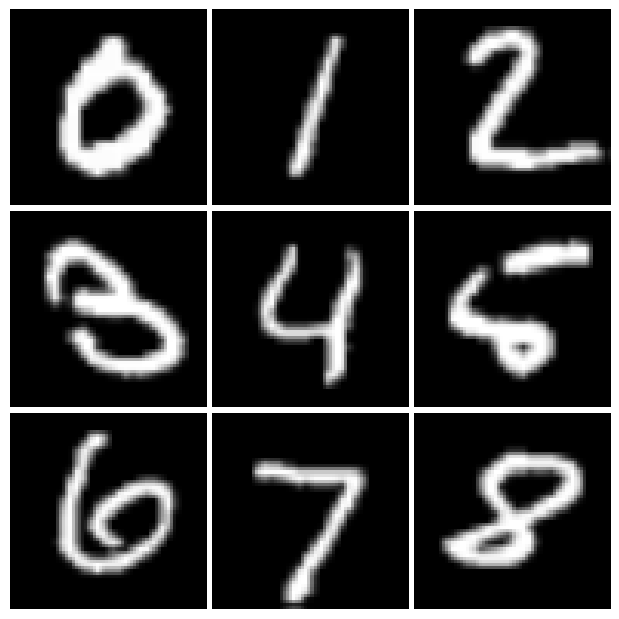

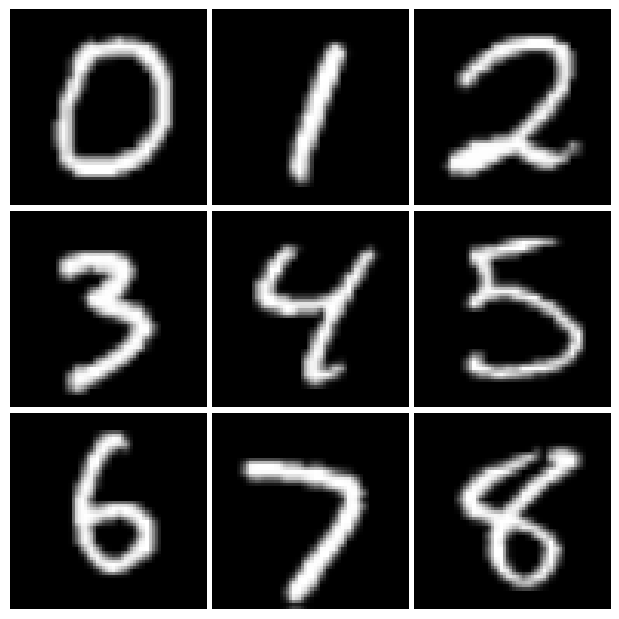

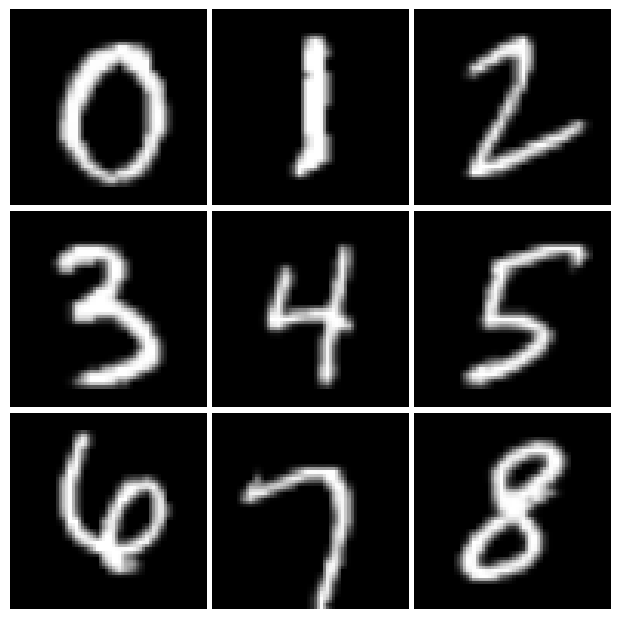

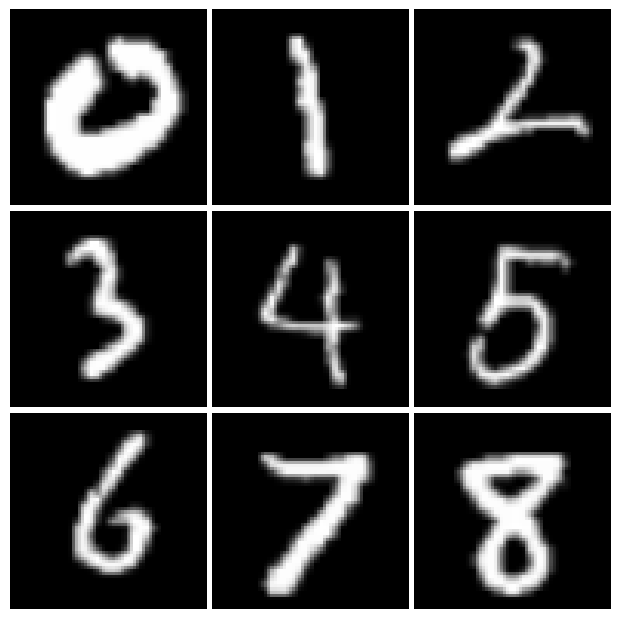

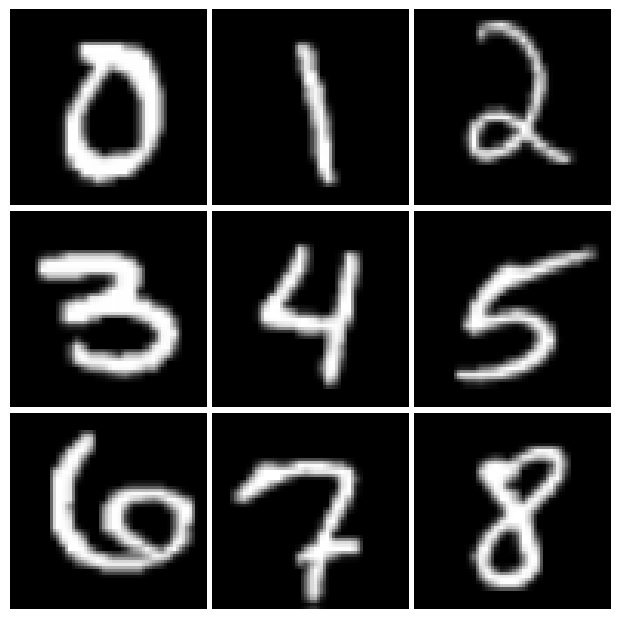

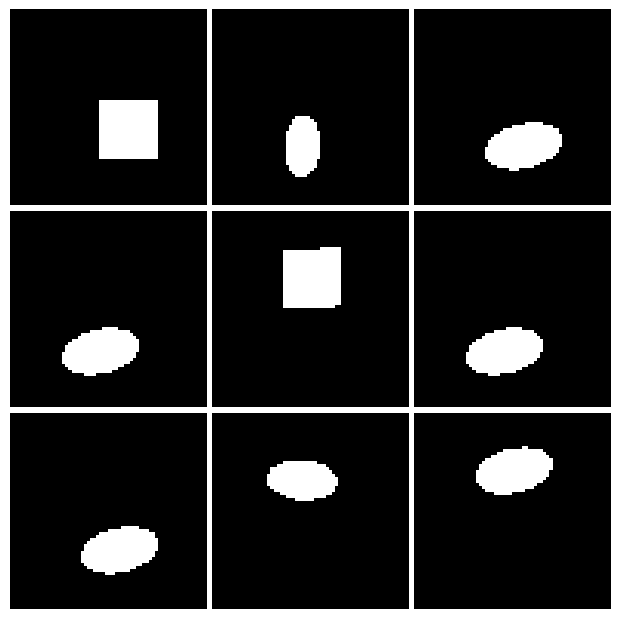

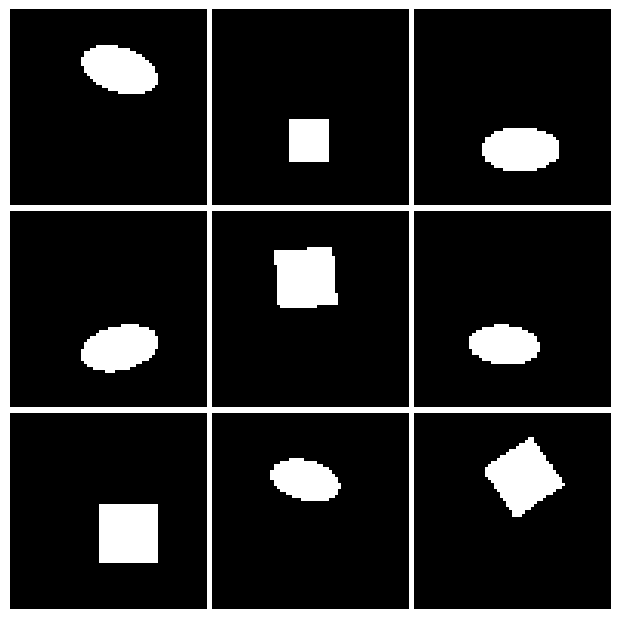

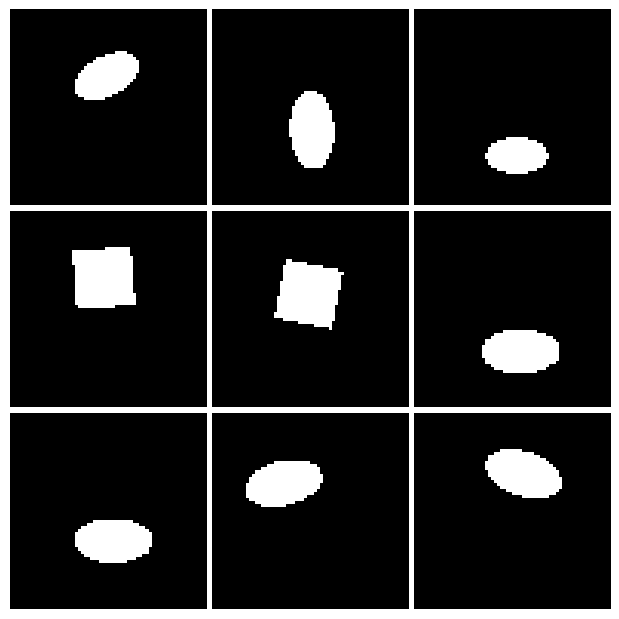

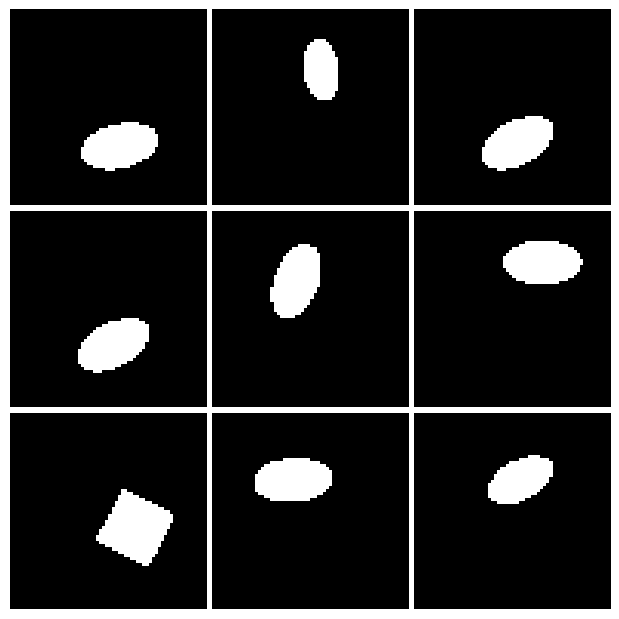

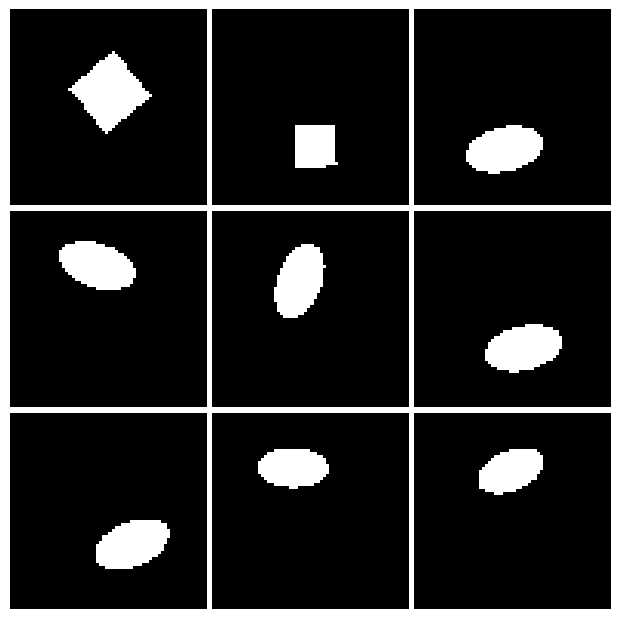

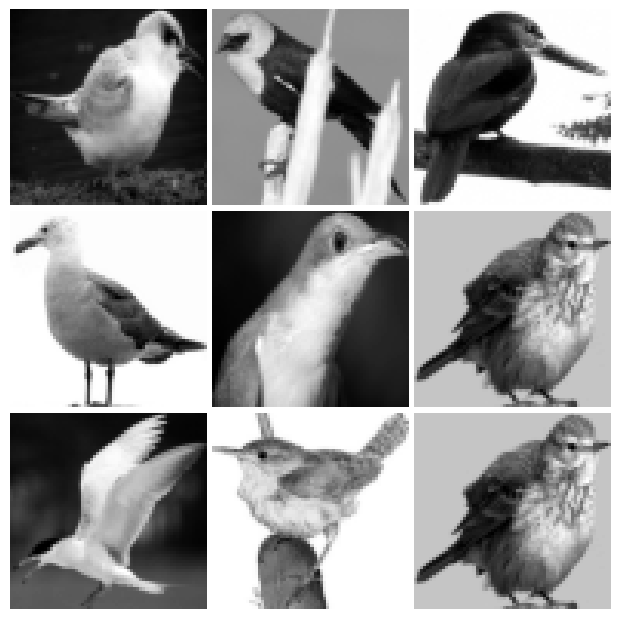

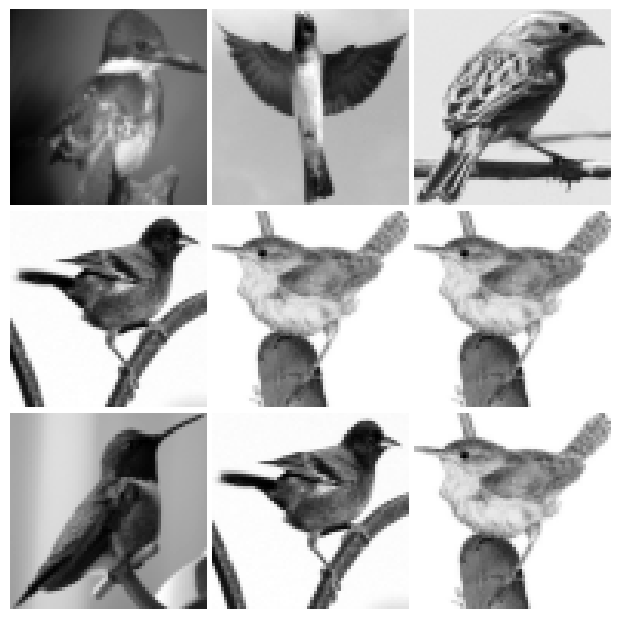

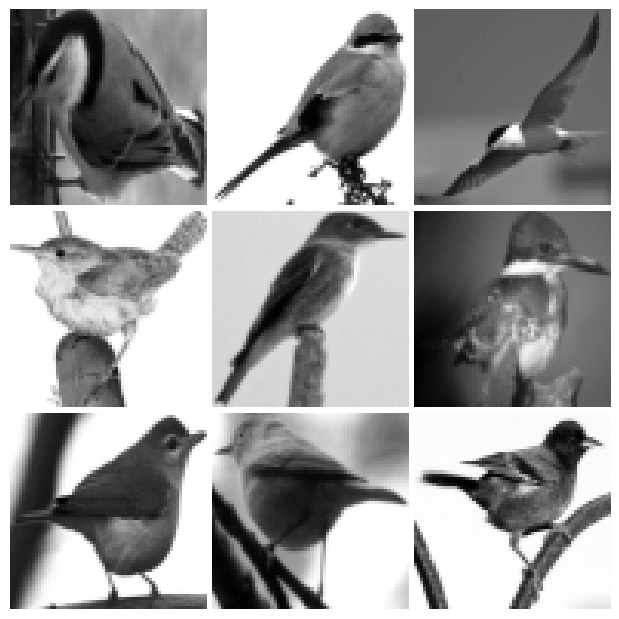

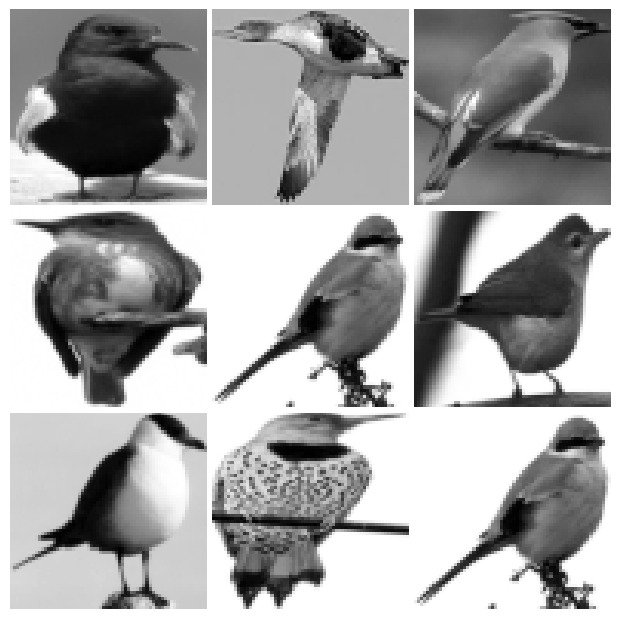

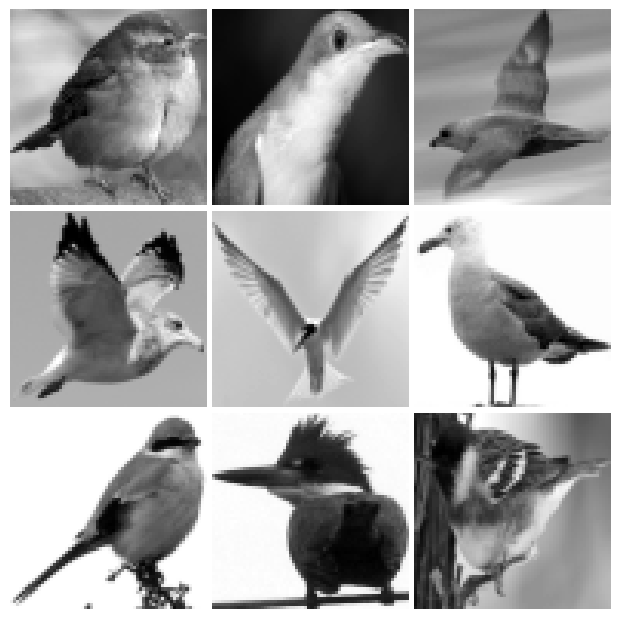

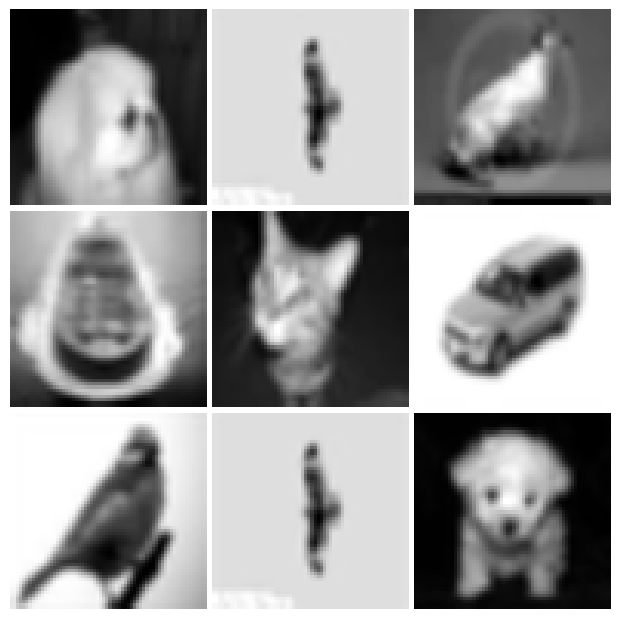

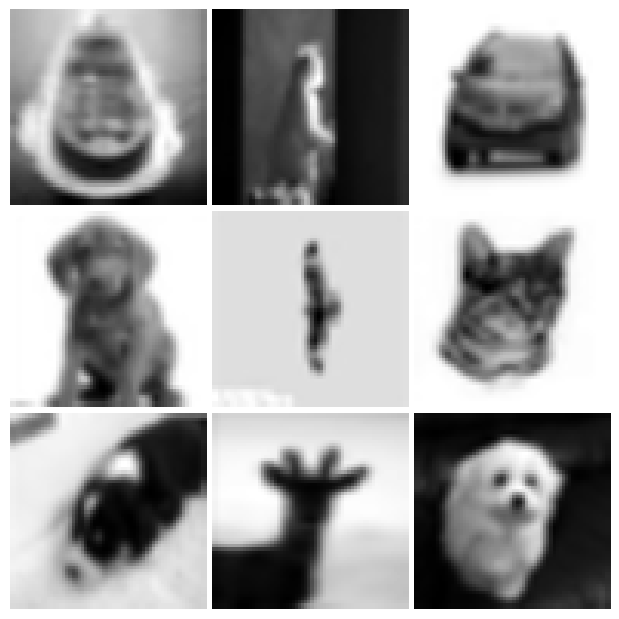

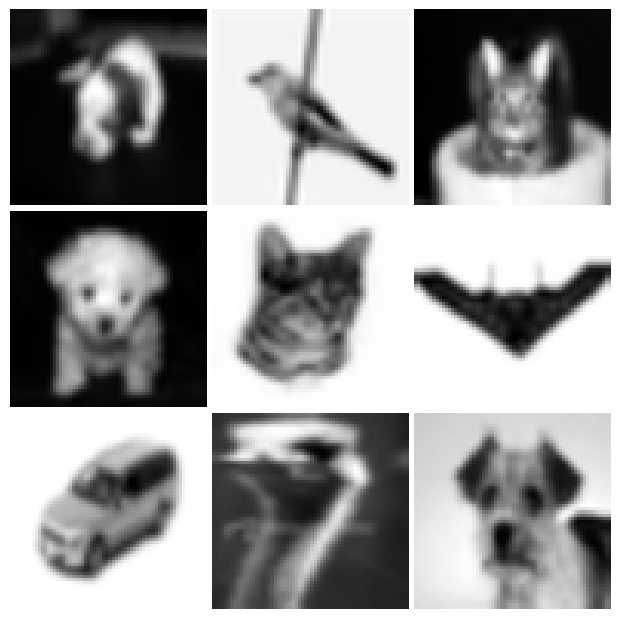

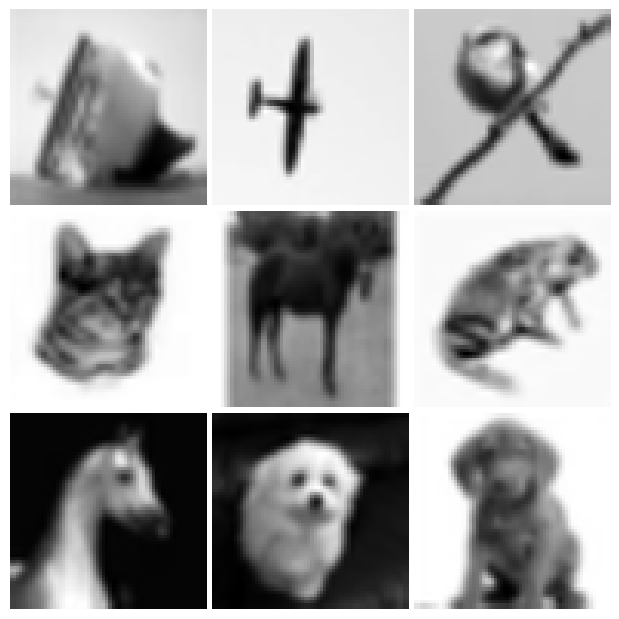

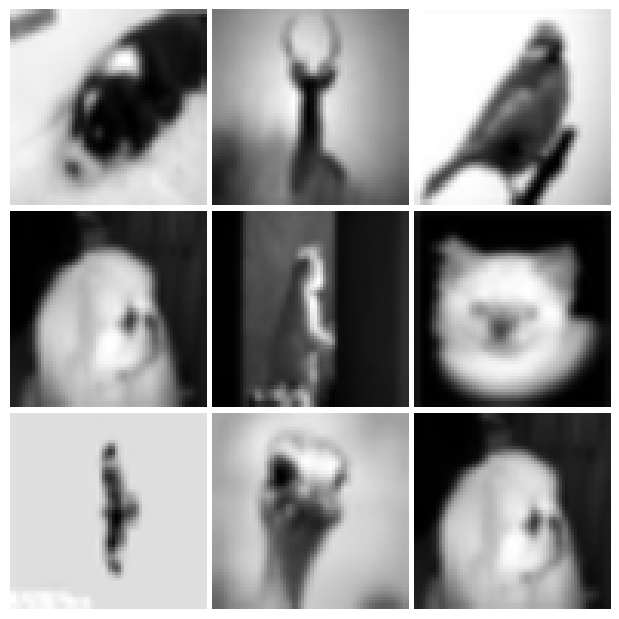

Saved 5 matrices each for ['digits', 'shapes', 'birds', 'objects'] -> ./frames/


In [7]:
import os
N_VARIANTS = 5          # how many matrices per dataset
NDIG = 9                # digits 0-8 -> 3x3
FRAME_DIR = "frames"    # where the clean grids are saved
os.makedirs(FRAME_DIR, exist_ok=True)


def clean_matrix(imgs, out_path):
    """3x3 grid, no titles / labels / ticks / borders — just the images."""
    fig, axes = plt.subplots(3, 3, figsize=(6, 6))
    for ax, im in zip(axes.ravel(), imgs):
        ax.imshow(im, cmap="gray")
        ax.axis("off")
    plt.subplots_adjust(wspace=0.03, hspace=0.03, left=0, right=1, top=1, bottom=0)
    fig.savefig(out_path, dpi=140, bbox_inches="tight", pad_inches=0.02)
    plt.show(); plt.close(fig)


def topk_variants(proto_mat, feats, disp, k, ndig=NDIG):
    """For each digit, the k best matches -> k matrices (variant r = r-th best per digit)."""
    mu = feats.mean(axis=0, keepdims=True) if CONFIG["MEAN_CENTER"] else 0.0
    S = cosine_matrix(proto_mat[:ndig] - mu, feats - mu)      # (ndig, N)
    ranks = np.argsort(-S, axis=1)[:, :k]                     # (ndig, k)
    return [[disp[ranks[i, r]] for i in range(ndig)] for r in range(k)]


def digit_variants(mnist, size, k, ndig=NDIG):
    """k matrices of real MNIST samples — a different example per digit each time."""
    return [[to_feature_image(mnist[d][r % len(mnist[d])], size) for d in range(ndig)]
            for r in range(k)]


sets = {
    "digits":  digit_variants(mnist, size, N_VARIANTS),
    "shapes":  topk_variants(proto_mat, shape_feats, shape_disp, N_VARIANTS),
    "birds":   topk_variants(proto_mat, bird_feats,  bird_disp,  N_VARIANTS),
    "objects": topk_variants(proto_mat, obj_feats,   obj_disp,   N_VARIANTS),
}

for name, variants in sets.items():
    for r, imgs in enumerate(variants):
        clean_matrix(imgs, os.path.join(FRAME_DIR, f"{name}_{r+1}.png"))

print(f"Saved {N_VARIANTS} matrices each for {list(sets)} -> ./{FRAME_DIR}/")

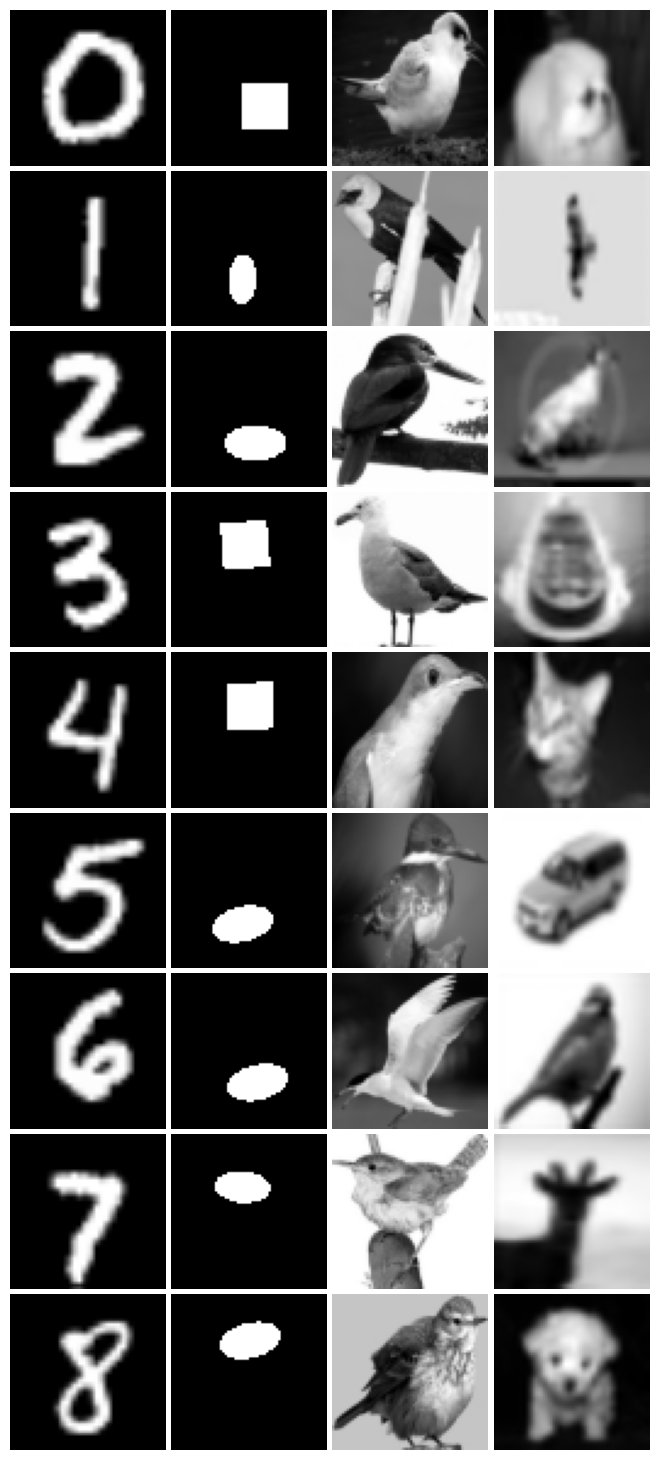

Saved collage_equivalents.png


In [8]:
# One collage image: 4 columns (digit | shape | bird | object), one row per digit.
NROWS = len(shape_imgs)          # digits 0-8 -> 9 rows
grid = [[thumbs[i], shape_imgs[i], bird_imgs[i], obj_imgs[i]] for i in range(NROWS)]

fig, axes = plt.subplots(NROWS, 4, figsize=(4 * 1.6, NROWS * 1.6))
for r in range(NROWS):
    for c in range(4):
        ax = axes[r, c]
        ax.imshow(grid[r][c], cmap="gray")
        ax.axis("off")
plt.subplots_adjust(wspace=0.03, hspace=0.03, left=0, right=1, top=1, bottom=0)
fig.savefig("collage_equivalents.png", dpi=140, bbox_inches="tight", pad_inches=0.02)
plt.show()
print("Saved collage_equivalents.png")

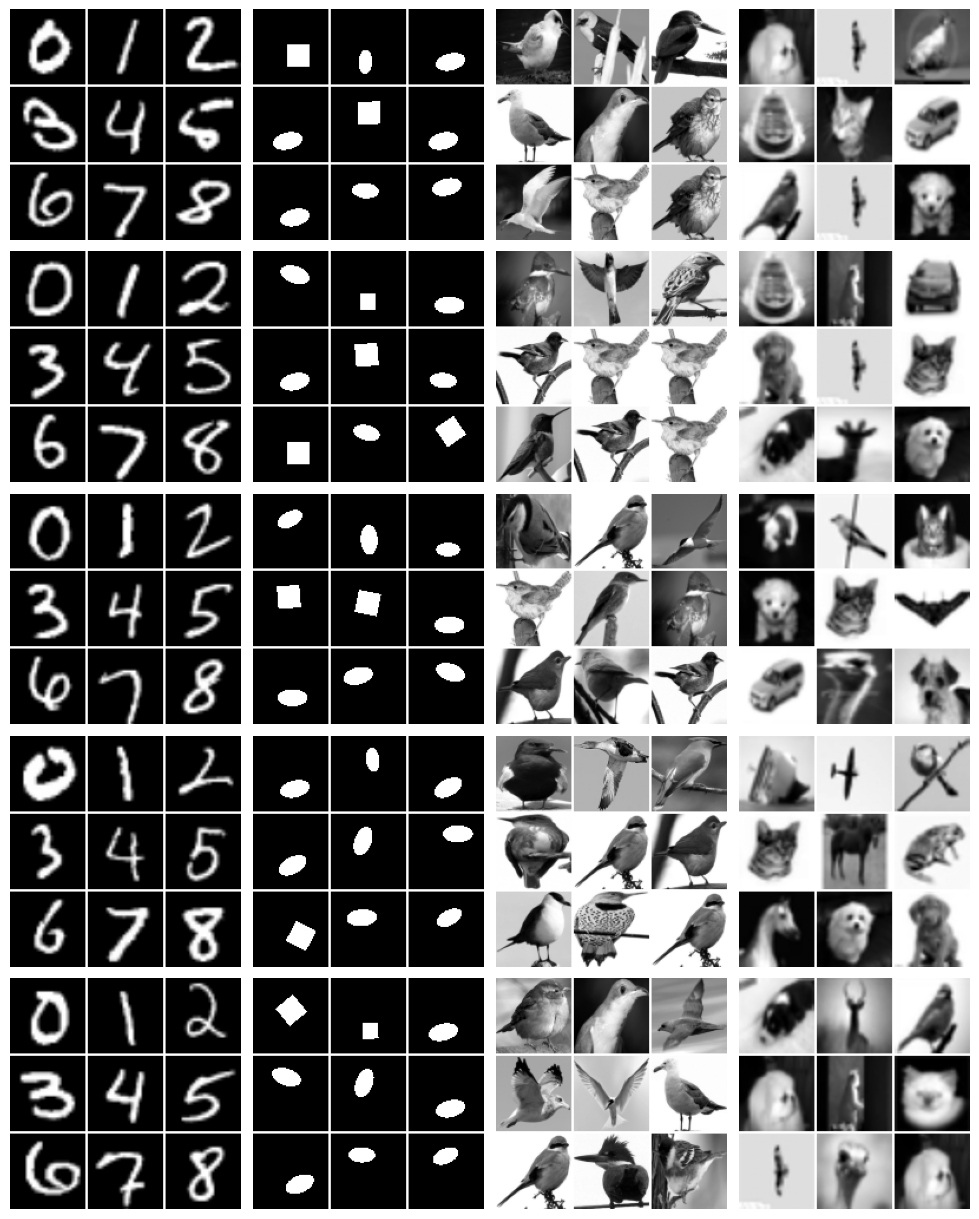

Saved collage_sets_5rows.png


In [9]:
import numpy as np
N_VARIANTS = 5     # rows: variant 1..5
NDIG = 9           # each block is a 3x3 (digits 0-8)


def topk_variants(proto_mat, feats, disp, k, ndig=NDIG):
    """For each digit, the k best matches -> k blocks (variant r = r-th best per digit)."""
    mu = feats.mean(axis=0, keepdims=True) if CONFIG["MEAN_CENTER"] else 0.0
    S = cosine_matrix(proto_mat[:ndig] - mu, feats - mu)
    ranks = np.argsort(-S, axis=1)[:, :k]
    return [[disp[ranks[i, r]] for i in range(ndig)] for r in range(k)]


def digit_variants(mnist, size, k, ndig=NDIG):
    """k blocks of real MNIST samples — a different example per digit each time."""
    return [[to_feature_image(mnist[d][r % len(mnist[d])], size) for d in range(ndig)]
            for r in range(k)]


def tile_3x3(imgs, gap=2, pad_val=1.0):
    """Collage 9 images into one 3x3 array with thin white gaps."""
    h, w = imgs[0].shape
    canvas = np.full((3 * h + 2 * gap, 3 * w + 2 * gap), pad_val, np.float32)
    for idx, im in enumerate(imgs):
        r, c = divmod(idx, 3)
        canvas[r * (h + gap):r * (h + gap) + h, c * (w + gap):c * (w + gap) + w] = im
    return canvas


order = ["digits", "shapes", "birds", "objects"]
sets = {
    "digits":  digit_variants(mnist, size, N_VARIANTS),
    "shapes":  topk_variants(proto_mat, shape_feats, shape_disp, N_VARIANTS),
    "birds":   topk_variants(proto_mat, bird_feats,  bird_disp,  N_VARIANTS),
    "objects": topk_variants(proto_mat, obj_feats,   obj_disp,   N_VARIANTS),
}

fig, axes = plt.subplots(N_VARIANTS, 4, figsize=(4 * 2.4, N_VARIANTS * 2.4))
for r in range(N_VARIANTS):
    for c, name in enumerate(order):
        ax = axes[r, c]
        ax.imshow(tile_3x3(sets[name][r]), cmap="gray")
        ax.axis("off")
plt.subplots_adjust(wspace=0.05, hspace=0.05, left=0, right=1, top=1, bottom=0)
fig.savefig("collage_sets_5rows.png", dpi=140, bbox_inches="tight", pad_inches=0.05)
plt.show()
print("Saved collage_sets_5rows.png")